In [1]:
from torchvision import datasets, transforms # Для работы с CIFAR-10
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

In [7]:
data_root = Path('../data/cifar10_raw')

# Определяем преобразование: PIL Image -> тензор PyTorch
transform = transforms.ToTensor()

# Загружаем тренировочную часть CIFAR-10
train_dataset = datasets.CIFAR10(
    root=data_root,      # Куда скачать
    train=True,          # Тренировочная часть (50.000 изображений)
    download=True,       # Скачать если нет локально
    transform=transform  # Применить преобразование
)

print(f"✅ CIFAR-10 загружен")
print(f"   Всего изображений: {len(train_dataset)}")
print(f"   Размер одного изображения: {train_dataset[0][0].shape}")

✅ CIFAR-10 загружен
   Всего изображений: 50000
   Размер одного изображения: torch.Size([3, 32, 32])


In [3]:
base_dir = Path('../data/processed/cifar10')
color_dir = base_dir / 'color'
gray_dir = base_dir / 'gray'

# Создаём папки (exist_ok=True не вызовет ошибку если папки уже существуют)
color_dir.mkdir(parents=True, exist_ok=True)
gray_dir.mkdir(parents=True, exist_ok=True)

print(f"✅ Папки созданы:")
print(f"   Цветные: {color_dir}")
print(f"   Ч/Б: {gray_dir}")

✅ Папки созданы:
   Цветные: ..\data\processed\cifar10\color
   Ч/Б: ..\data\processed\cifar10\gray


In [8]:
# Сколько пар сохранить
num_pairs_to_save = 1000

print(f"Создаю {num_pairs_to_save} пар изображений...")

for i in range(num_pairs_to_save):
    # img_tensor - тензор [3, 32, 32] с цветным изображением
    # label - метка класса (нам не нужна для колоризации)
    img_tensor, label = train_dataset[i]

    color_img = transforms.ToPILImage()(img_tensor) # Конвертируем тензор обратно в PIL Image для сохранения
    color_path = color_dir / f'{i:05d}.png' # :05d означает что номер будет дополнен нулями до 5 цифр
    color_img.save(color_path)

    gray_img = color_img.convert('L')
    gray_path = gray_dir / f'{i:05d}.png' # То же имя файла!
    gray_img.save(gray_path)

print(f"✅ Готово! Сохранено {num_pairs_to_save} пар")

Создаю 1000 пар изображений...
✅ Готово! Сохранено 1000 пар


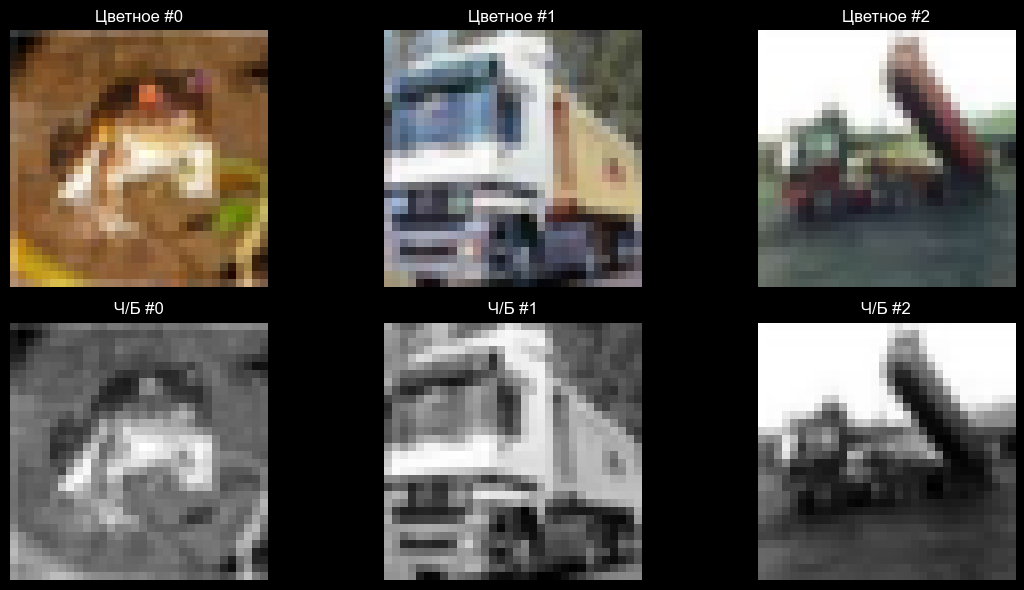

In [9]:
num_to_display = 3
fig, axes = plt.subplots(2, num_to_display, figsize=(12, 6))

for i in range(num_to_display):
    filename = f'{i:05d}.png'

    color_path = color_dir / filename
    color_img = Image.open(color_path)

    gray_path = gray_dir / filename
    gray_img = Image.open(gray_path)

    axes[0, i].imshow(color_img)
    axes[0, i].set_title(f'Цветное #{i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(gray_img, cmap='gray')
    axes[1, i].set_title(f'Ч/Б #{i}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [10]:
print("📊 Проверка целостности данных:")

color_files = sorted([f.name for f in color_dir.iterdir() if f.is_file()])
gray_files = sorted([f.name for f in gray_dir.iterdir() if f.is_file()])

print(f"   Файлов в color/: {len(color_files)}")
print(f"   Файлов в gray/: {len(gray_files)}")

# Проверяем совпадение имён через множества
if set(color_files) == set(gray_files):
    print("✅ Имена файлов совпадают")
else:
    print("❌ Имена файлов НЕ совпадают!")

# Проверяем размеры
print("\n🔍 Проверка размеров изображений:")
for i in range(min(3, len(color_files))):
    color_img = Image.open(color_dir / color_files[i])
    gray_img = Image.open(gray_dir / gray_files[i])

    print(f"   {color_files[i]}: цветное {color_img.size}, ч/б {gray_img.size}",
          "✅" if color_img.size == gray_img.size else "❌")

print("\n🎯 Данные готовы для обучения!")

📊 Проверка целостности данных:
   Файлов в color/: 1000
   Файлов в gray/: 1000
✅ Имена файлов совпадают

🔍 Проверка размеров изображений:
   00000.png: цветное (32, 32), ч/б (32, 32) ✅
   00001.png: цветное (32, 32), ч/б (32, 32) ✅
   00002.png: цветное (32, 32), ч/б (32, 32) ✅

🎯 Данные готовы для обучения!


## Выводы

✅ CIFAR-10 успешно загружен и подготовлен для задачи колоризации

✅ Данные готовы для обучения нейросетевой модели